Generating plot for Beijing...


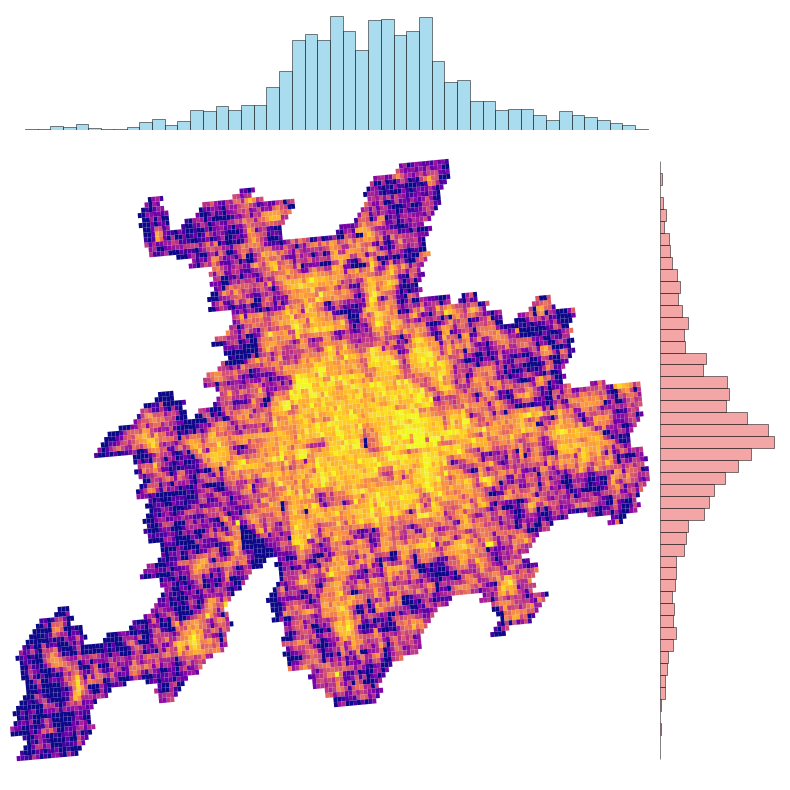

Successfully saved and closed plot for Beijing.

Generating plot for Shijiazhuang...


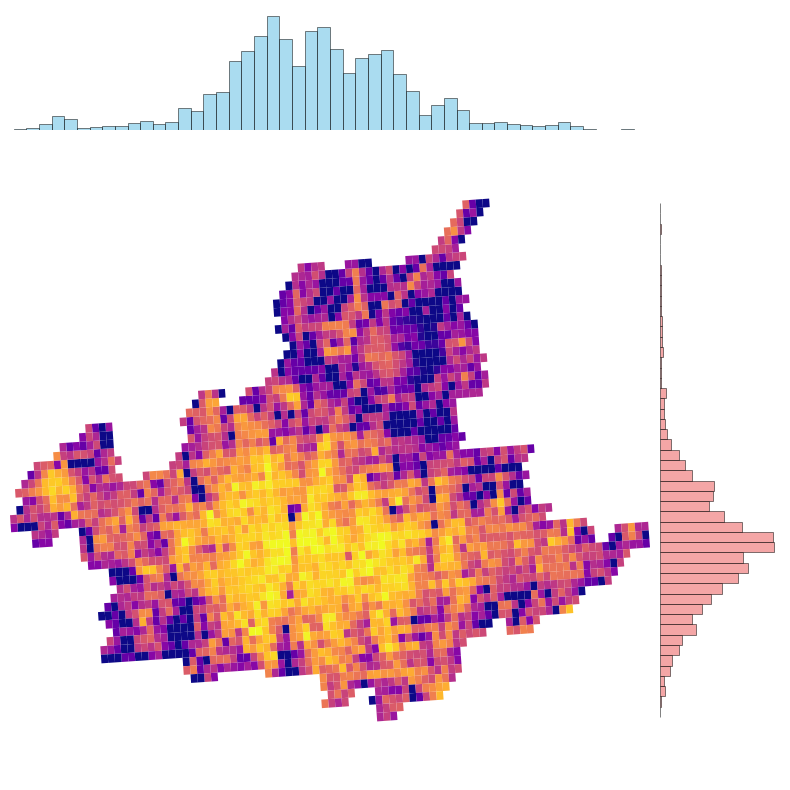

Successfully saved and closed plot for Shijiazhuang.

Generating plot for Suzhou...


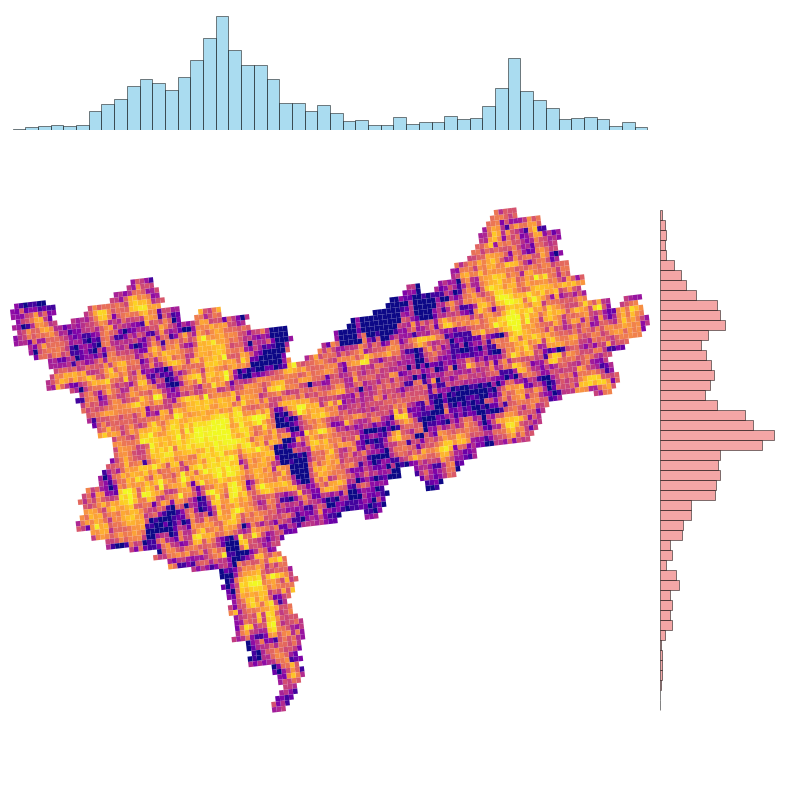

Successfully saved and closed plot for Suzhou.

Generating plot for Dongguan...


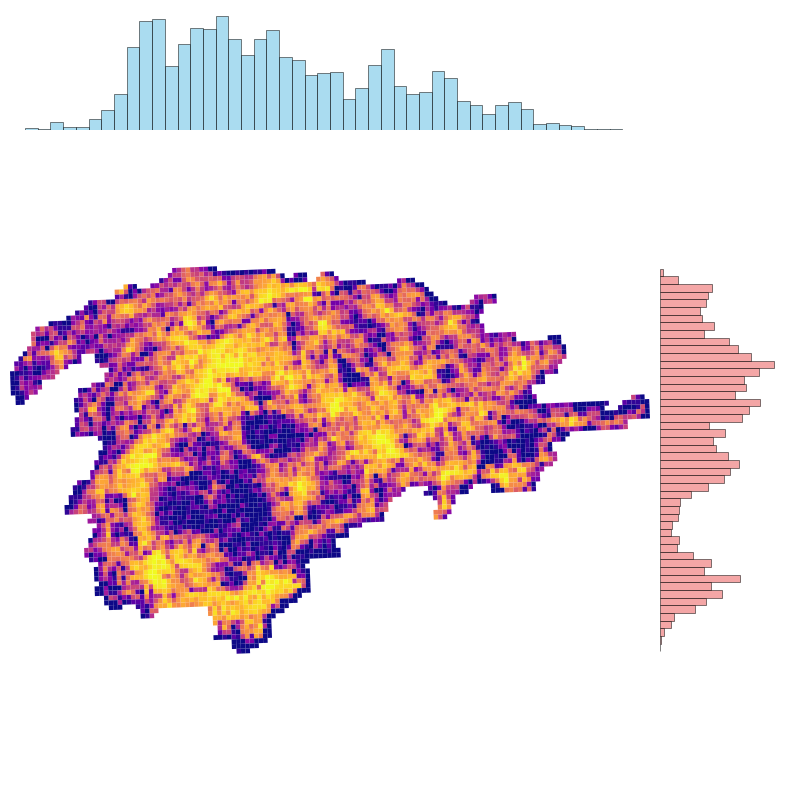

Successfully saved and closed plot for Dongguan.



In [1]:
import numpy as np
import geopandas
import pyproj
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings

warnings.filterwarnings("ignore")

cities = ['Beijing', 'Shijiazhuang', 'Suzhou', 'Dongguan']
feature = 'pop_norm'
p1 = pyproj.Proj('epsg:4793')

for city_name in cities:
    print(f"Generating plot for {city_name}...")

    grid_shp = geopandas.read_file(
        rf'E:\experienced segregation in 15 min cities\Code and Data\source data\neighborhood-level walkability\{city_name}_neighborhoods.json')

    plot_shp = grid_shp.to_crs("EPSG:4793")
    plot_shp.loc[plot_shp[feature] <= 0, feature] = 1e-6

    min_set = np.percentile(plot_shp[feature],5)
    max_set = np.percentile(plot_shp[feature],99)
    jet = plt.get_cmap('plasma')
    cNorm = colors.LogNorm(vmin=min_set, vmax=max_set)
    plot_shp['color'] = plot_shp[feature].apply(lambda x: jet(cNorm(x)))

    plot_shp['centroid'] = plot_shp.geometry.centroid
    plot_shp['x'] = plot_shp['centroid'].x
    plot_shp['y'] = plot_shp['centroid'].y

    xmin, ymin, xmax, ymax = plot_shp.total_bounds
    wide_d = np.max([xmax - xmin, ymax - ymin])

    midy = (ymax + ymin) / 2.0
    ymin = midy - wide_d / 2.0
    ymax = midy + wide_d / 2.0
    midx = (xmax + xmin) / 2.0
    xmin = midx - wide_d / 2.0
    xmax = midx + wide_d / 2.0

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    plot_shp.plot(ax=ax, color=plot_shp['color'], linewidth=0.1, zorder=3)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    divider = make_axes_locatable(ax)

    ax_histx = divider.append_axes("top", 1.2, pad=0.1, sharex=ax)
    ax_histx.hist(plot_shp['x'], weights=plot_shp[feature], bins=50,
                  color='skyblue', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax_histx.set_ylabel('POIs Sum')
    ax_histx.tick_params(axis='x', labelbottom=False)
    ax_histx.axis('off')

    ax_histy = divider.append_axes("right", 1.2, pad=0.1, sharey=ax)
    ax_histy.hist(plot_shp['y'], weights=plot_shp[feature], bins=50,
                  orientation='horizontal', color='lightcoral', alpha=0.7,
                  edgecolor='black', linewidth=0.5)
    ax_histy.set_xlabel('POIs Sum')
    ax_histy.tick_params(axis='y', labelleft=False)
    ax_histy.axis('off')

    plt.savefig(f'F:/{city_name}_population_with_hist.svg', bbox_inches='tight')
    plt.show()

    plt.close(fig)
    print(f"Successfully saved and closed plot for {city_name}.\n")
